# PIFT Phase A Workbench

This notebook runs tests, executes the forward PIFT example, and visualizes outputs.

In [4]:
from pathlib import Path
import os

ROOT = Path.cwd()
if ROOT.name == 'examples':
    ROOT = ROOT.parent

os.chdir(ROOT)
print('Repo root:', ROOT)

cache_dir = ROOT / 'outputs' / '.cache'
(cache_dir / 'matplotlib').mkdir(parents=True, exist_ok=True)
(cache_dir / 'fontconfig').mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(cache_dir / 'matplotlib')
os.environ['XDG_CACHE_HOME'] = str(cache_dir)

for p in [ROOT / 'outputs' / 'figures', ROOT / 'outputs' / 'traces', ROOT / 'outputs' / 'tables']:
    p.mkdir(parents=True, exist_ok=True)

Repo root: /Users/chobbs/Desktop/Personal Projects/pift-od-il-inverse-problems


## 1a) Ensure notebook dependencies are installed in this kernel\n
Run this once per environment.

In [5]:
import sys, subprocess
print('Kernel python:', sys.executable)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', '.'], check=True)

Kernel python: /Users/chobbs/Desktop/Personal Projects/pift-od-il-inverse-problems/.venv/bin/python
Obtaining file:///Users/chobbs/Desktop/Personal%20Projects/pift-od-il-inverse-problems
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for pift-od-il-inverse-problems (pyproject.toml): started
  Building editable for pift-od-il-inverse-problems (pyproject.toml): finished with status 'done'
  Created wheel for pift-od-il-inverse-problems: filename=pift_od_il_inverse_problems-0.1.0-0.editable-py3-none-any.whl size=6250 sha256=3f14


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['/Users/chobbs/Desktop/Personal Projects/pift-od-il-inverse-problems/.venv/bin/python', '-m', 'pip', 'install', '-e', '.'], returncode=0)

## 1) Run unit tests

In [6]:
import subprocess
import sys

print('Using interpreter:', sys.executable)
result = subprocess.run([sys.executable, '-m', 'pytest', '-q'], text=True, capture_output=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError('Tests failed. See output above.')

Using interpreter: /Users/chobbs/Desktop/Personal Projects/pift-od-il-inverse-problems/.venv/bin/python
.......                                                                  [100%]
7 passed in 7.45s



## 2) Run Phase A forward pipeline

In [9]:
import subprocess

result = subprocess.run(['bash', 'scripts/run_forward.sh'], text=True, capture_output=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError('Forward run failed. See output above.')

Phase A forward run complete
{
  "config": {
    "seed": 7,
    "n_modes": 12,
    "n_obs": 28,
    "noise_std": 0.08,
    "beta": 12.0,
    "n_steps": 16000,
    "burn_in": 4000,
    "thin": 8,
    "step_size0": 0.002,
    "decay": 0.55,
    "n_quad": 96,
    "n_grid": 300
  },
  "n_posterior_samples": 1500,
  "l2_error": NaN,
  "max_error": NaN,
  "hamiltonian_lag1_autocorr": NaN,
  "measurement_interval_coverage_90pct": 0.0
}



## 3) Inspect generated summary

In [10]:
import json

summary_path = ROOT / 'outputs' / 'tables' / 'phase_a_forward_poisson_summary.json'
with open(summary_path, 'r', encoding='utf-8') as f:
    summary = json.load(f)
summary

{'config': {'seed': 7,
  'n_modes': 12,
  'n_obs': 28,
  'noise_std': 0.08,
  'beta': 12.0,
  'n_steps': 16000,
  'burn_in': 4000,
  'thin': 8,
  'step_size0': 0.002,
  'decay': 0.55,
  'n_quad': 96,
  'n_grid': 300},
 'n_posterior_samples': 1500,
 'l2_error': nan,
 'max_error': nan,
 'hamiltonian_lag1_autocorr': nan,
 'measurement_interval_coverage_90pct': 0.0}

## 4) Show generated plots

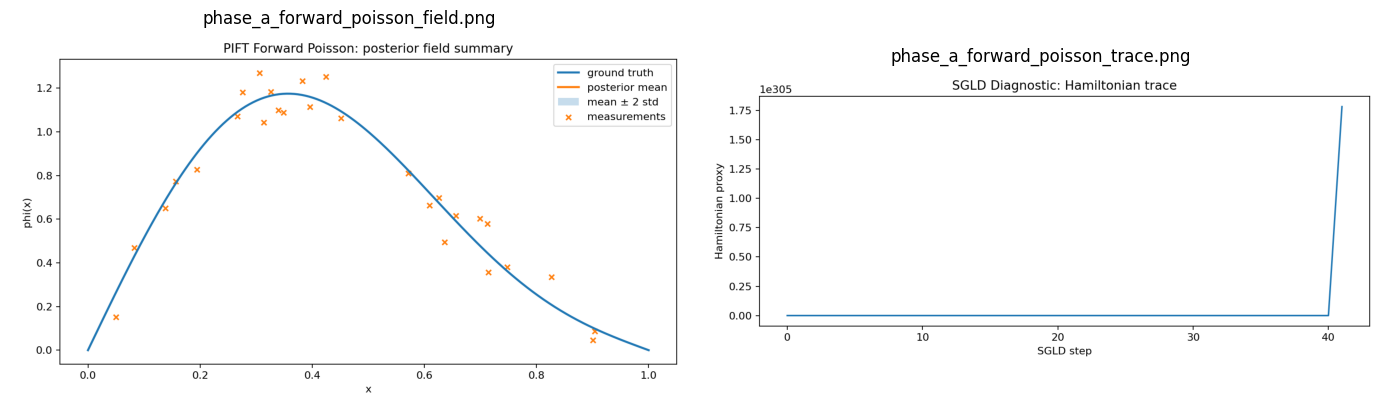

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig_paths = [
    ROOT / 'outputs' / 'figures' / 'phase_a_forward_poisson_field.png',
    ROOT / 'outputs' / 'figures' / 'phase_a_forward_poisson_trace.png',
]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for ax, p in zip(axs, fig_paths):
    img = mpimg.imread(p)
    ax.imshow(img)
    ax.set_title(p.name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5) Create a pipeline diagram artifact

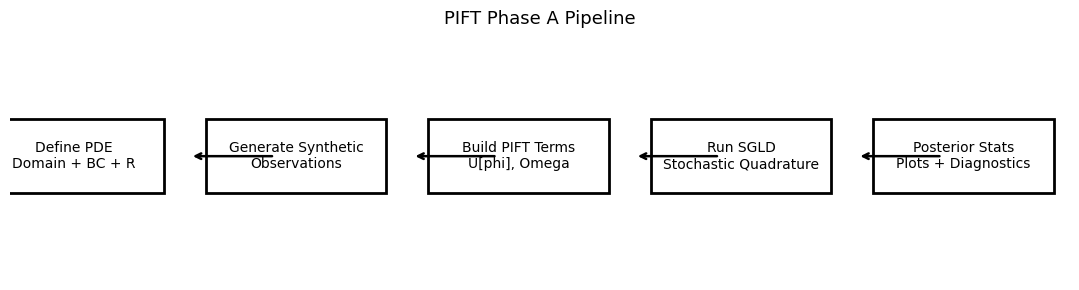

Saved: /Users/chobbs/Desktop/Personal Projects/pift-od-il-inverse-problems/outputs/figures/phase_a_pipeline_diagram.png


In [12]:
import matplotlib.pyplot as plt

diagram_path = ROOT / 'outputs' / 'figures' / 'phase_a_pipeline_diagram.png'

fig, ax = plt.subplots(figsize=(11, 3))
ax.axis('off')

labels = [
    'Define PDE\nDomain + BC + R',
    'Generate Synthetic\nObservations',
    'Build PIFT Terms\nU[phi], Omega',
    'Run SGLD\nStochastic Quadrature',
    'Posterior Stats\nPlots + Diagnostics',
]
x_positions = [0.06, 0.27, 0.48, 0.69, 0.90]

for i, (x, label) in enumerate(zip(x_positions, labels)):
    box = plt.Rectangle((x - 0.085, 0.35), 0.17, 0.30, fill=False, linewidth=2)
    ax.add_patch(box)
    ax.text(x, 0.50, label, ha='center', va='center', fontsize=10)
    if i < len(labels) - 1:
        ax.annotate('', xy=(x + 0.11, 0.50), xytext=(x + 0.19, 0.50),
                    arrowprops=dict(arrowstyle='->', lw=1.8))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('PIFT Phase A Pipeline', fontsize=13)
plt.tight_layout()
plt.savefig(diagram_path, dpi=180)
plt.show()
print('Saved:', diagram_path)